# Deep-network trainability autopsy

One dataset, one 30-hidden-layer network, and one Adam learning rate. We first change
only the scale of the same randomly sampled weights, then repair the failing
network with normalization or a residual route.

**Predict before each reveal.** The useful habit is not memorizing a preferred
architecture; it is reading layerwise evidence before changing one cause.

In [1]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

torch.set_num_threads(min(4, torch.get_num_threads()))
torch.manual_seed(11)

INK = "#23373B"
ACC = "#EB811B"
TEAL = "#2C7A7B"
GREEN = "#14B03D"
BLUE = "#2B6CB0"
MUTED = "#6E7F82"
RED = "#D64550"
colors = {0.5: BLUE, 1.0: GREEN, 1.5: RED}

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "text.color": INK,
})
print("torch", torch.__version__)

torch 2.13.0


## 1 · The fixed patient

The 3-class spiral is deliberately small and visible. The model is
$2 \rightarrow [\mathrm{Linear}(128)\rightarrow\mathrm{ReLU}]\times30
\rightarrow3$. Every training comparison uses full-batch cross-entropy and
Adam with learning rate $3\times10^{-4}$.

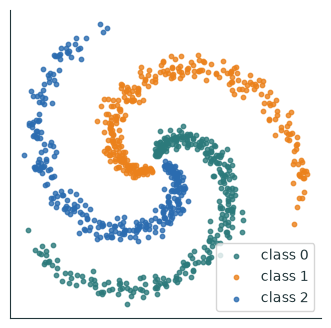

X (900, 2) y (900,)


In [2]:
def make_spiral(n_per_class=300, classes=3, noise=0.2, seed=7):
    generator = torch.Generator().manual_seed(seed)
    points, labels = [], []
    for class_id in range(classes):
        radius = torch.linspace(0.05, 1.0, n_per_class)
        angle = (
            torch.linspace(class_id * 4.0, (class_id + 1) * 4.0, n_per_class)
            + noise * torch.randn(n_per_class, generator=generator)
        )
        points.append(torch.stack((radius * torch.sin(angle), radius * torch.cos(angle)), dim=1))
        labels.append(torch.full((n_per_class,), class_id, dtype=torch.long))
    x = torch.cat(points)
    y = torch.cat(labels)
    order = torch.randperm(len(x), generator=generator)
    return x[order], y[order]


X, y = make_spiral()
for class_id, color in enumerate((TEAL, ACC, BLUE)):
    mask = y == class_id
    plt.scatter(X[mask, 0], X[mask, 1], s=10, color=color, alpha=0.8, label=f"class {class_id}")
plt.gca().set_aspect("equal")
plt.xticks([]); plt.yticks([]); plt.legend(); plt.show()
print("X", tuple(X.shape), "y", tuple(y.shape))

In [3]:
def initialize_linear(layer, alpha):
    nn.init.normal_(layer.weight, 0.0, math.sqrt(2 / layer.in_features))
    nn.init.zeros_(layer.bias)
    with torch.no_grad():
        layer.weight.mul_(alpha)


class DeepSpiralMLP(nn.Module):
    def __init__(self, alpha, route="plain", depth=30, width=128, seed=11):
        super().__init__()
        assert route in {"plain", "batchnorm", "residual"}
        torch.manual_seed(seed)
        self.route = route

        if route in {"plain", "batchnorm"}:
            self.hidden = nn.ModuleList()
            self.norms = nn.ModuleList()
            incoming = 2
            for _ in range(depth):
                layer = nn.Linear(incoming, width)
                initialize_linear(layer, alpha)
                self.hidden.append(layer)
                if route == "batchnorm":
                    self.norms.append(nn.BatchNorm1d(width))
                incoming = width
        else:
            self.stem = nn.Linear(2, width)
            initialize_linear(self.stem, alpha)
            self.hidden = nn.ModuleList()
            for _ in range(depth - 1):
                layer = nn.Linear(width, width)
                initialize_linear(layer, alpha)
                self.hidden.append(layer)

        self.output = nn.Linear(width, 3)
        initialize_linear(self.output, alpha)

    def forward(self, x, retain_intermediates=False):
        activations = []
        if self.route == "plain":
            for layer in self.hidden:
                x = F.relu(layer(x))
                if retain_intermediates: x.retain_grad()
                activations.append(x)
        elif self.route == "batchnorm":
            for layer, norm in zip(self.hidden, self.norms):
                x = F.relu(norm(layer(x)))
                if retain_intermediates: x.retain_grad()
                activations.append(x)
        else:
            x = F.relu(self.stem(x))
            if retain_intermediates: x.retain_grad()
            activations.append(x)
            for layer in self.hidden:
                # Exact identity skip: h_next = h + F(h), with F(h) = ReLU(Wh).
                # There is deliberately no outer ReLU after the addition.
                x = x + F.relu(layer(x))
                if retain_intermediates: x.retain_grad()
                activations.append(x)
        return self.output(x), activations


def rms(tensor):
    return tensor.detach().float().square().mean().sqrt().item()

## 2 · Same directions, three volumes

For each $\alpha$, the model constructor draws the same base tensors with the
same seed and then applies $W_\ell\leftarrow\alpha W_\ell$. Verify the invariant
before interpreting any curve.

In [4]:
models = {alpha: DeepSpiralMLP(alpha) for alpha in (0.5, 1.0, 1.5)}
w_half = models[0.5].hidden[7].weight.detach()
w_one = models[1.0].hidden[7].weight.detach()
w_large = models[1.5].hidden[7].weight.detach()

print("0.5 directions preserved:", torch.allclose(w_half, 0.5 * w_one))
print("1.5 directions preserved:", torch.allclose(w_large, 1.5 * w_one))
print("same data, same Adam lr=3e-4, same architecture")

0.5 directions preserved: True
1.5 directions preserved: True
same data, same Adam lr=3e-4, same architecture


## 3 · Thirty small scale changes become one enormous change

For positive $α$, ReLU is positively homogeneous:

$$
\operatorname{ReLU}(αz)=α\operatorname{ReLU}(z).
$$

Our biases are zero and the weight *directions* are fixed. Therefore, before
training, every layer contributes one more factor of $α$:

$$
h_{30}(α)=α^{30}h_{30}(1).
$$

This is the worked example to keep in your head. Halving each weight does not
halve the layer-30 signal: $0.5^{30}\approx9.31\times10^{-10}$. Multiplying
each weight by $1.5$ gives $1.5^{30}\approx1.92\times10^5$. Let us compare
that prediction with the actual tensors.

In [5]:
def hidden_outputs(model):
    model.eval()
    with torch.no_grad():
        _, activations = model(X)
    model.train()
    return [h.detach().cpu() for h in activations]


initial_activations = {
    alpha: hidden_outputs(model) for alpha, model in models.items()
}
reference_rms = rms(initial_activations[1.0][-1])

print("The layer-30 prediction uses only alpha**30 and the measured alpha=1 RMS")
print(f"{'alpha':>6} {'alpha**30':>13} {'predicted RMS':>16} {'measured RMS':>16} {'measured/pred':>15}")
for alpha in (0.5, 1.0, 1.5):
    gain = alpha**30
    predicted = gain * reference_rms
    measured = rms(initial_activations[alpha][-1])
    print(f"{alpha:6.1f} {gain:13.5e} {predicted:16.5e} {measured:16.5e} {measured/predicted:15.6f}")

The layer-30 prediction uses only alpha**30 and the measured alpha=1 RMS
 alpha     alpha**30    predicted RMS     measured RMS   measured/pred
   0.5   9.31323e-10      1.02154e-09      1.02154e-09        1.000000
   1.0   1.00000e+00      1.09687e+00      1.09687e+00        1.000000
   1.5   1.91751e+05      2.10326e+05      2.10326e+05        1.000000


## 4 · The whole distribution tells the same story

Each panel below is an actual activation histogram from the fixed minibatch.
The horizontal scale is allowed to change from panel to panel; compare the
printed RMS values. Notice also that all three runs retain roughly half active
ReLUs. The units are not simply all “dead”—the signal scale is collapsing or
exploding while the sign pattern stays almost unchanged.

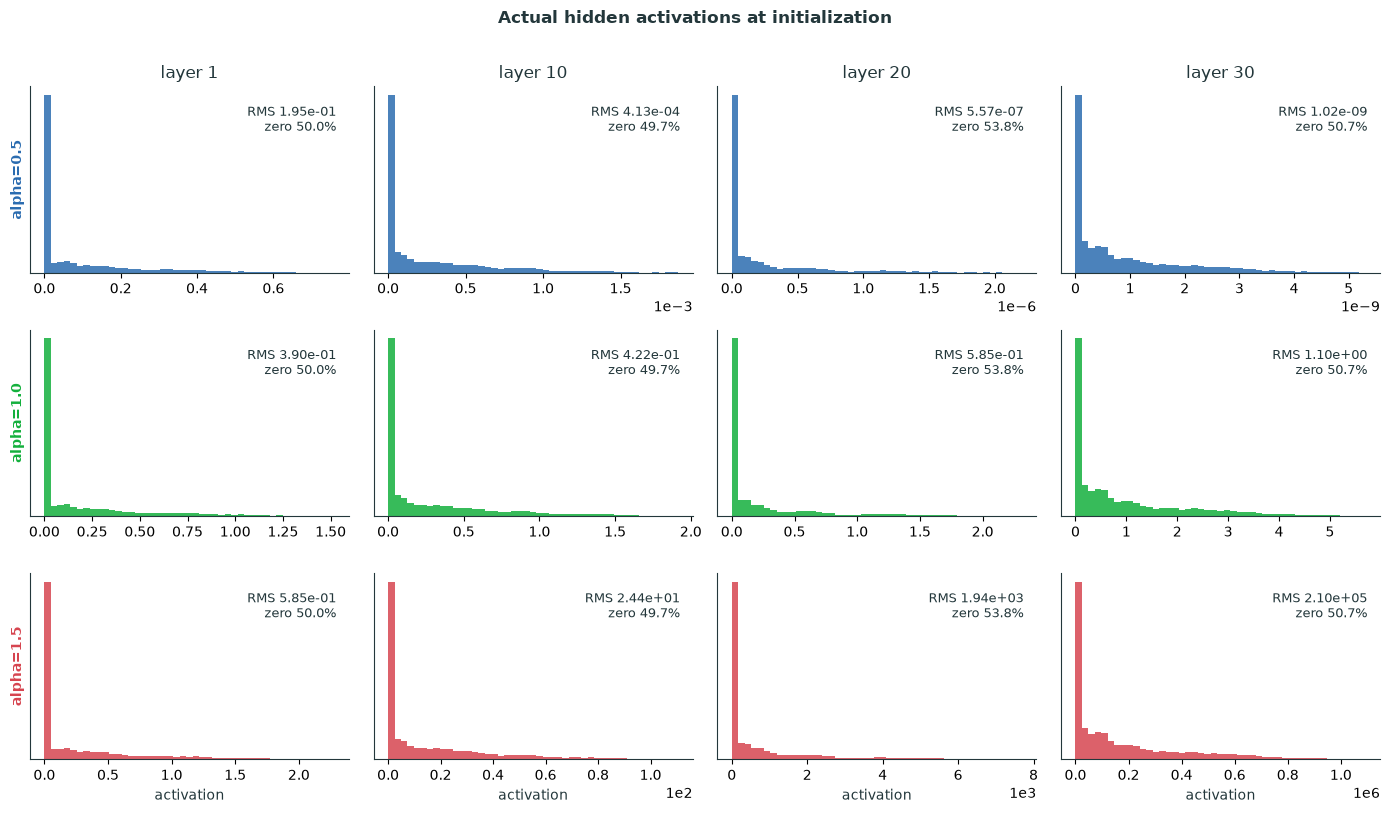

In [6]:
selected_layers = (1, 10, 20, 30)
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for row, alpha in enumerate((0.5, 1.0, 1.5)):
    for col, layer_number in enumerate(selected_layers):
        ax = axes[row, col]
        values = initial_activations[alpha][layer_number - 1].numpy().ravel()
        shown = values[::8]  # deterministic thinning for a faster plot
        upper = max(float(np.quantile(shown, 0.995)), 1e-12)
        ax.hist(shown, bins=45, range=(0, upper), color=colors[alpha], alpha=0.85)
        ax.set_yticks([])
        ax.ticklabel_format(axis="x", style="sci", scilimits=(-2, 2))
        ax.text(
            0.96,
            0.90,
            f"RMS {rms(initial_activations[alpha][layer_number - 1]):.2e}\n"
            f"zero {(values == 0).mean():.1%}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )
        if row == 0:
            ax.set_title(f"layer {layer_number}")
        if col == 0:
            ax.set_ylabel(f"alpha={alpha}", color=colors[alpha], fontweight="bold")
        if row == 2:
            ax.set_xlabel("activation")
plt.suptitle("Actual hidden activations at initialization", y=1.01, fontweight="bold")
plt.tight_layout(); plt.show()

## 5 · Autopsy at initialization

Before running an optimizer step, predict the three activation-RMS and
activation-gradient-RMS traces. Also predict whether the active-ReLU fraction
alone will identify the failure.

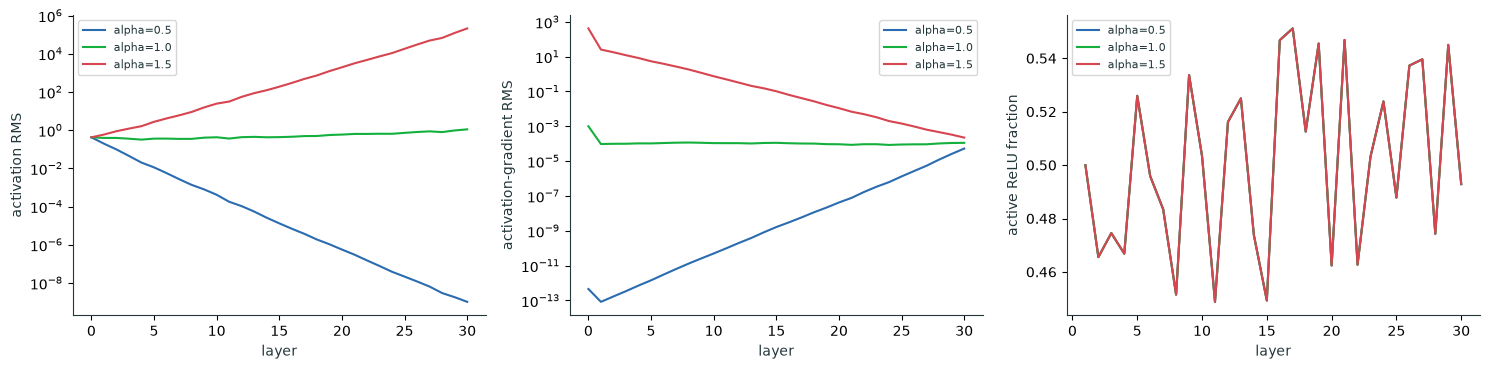

alpha=0.5: final activation RMS=1.022e-09; input-gradient RMS=4.570e-13; all finite=True
alpha=1.0: final activation RMS=1.097e+00; input-gradient RMS=1.009e-03; all finite=True
alpha=1.5: final activation RMS=2.103e+05; input-gradient RMS=4.154e+02; all finite=True


In [7]:
@dataclass
class Trace:
    activation_rms: list
    gradient_rms: list
    active_fraction: list
    finite: list


def trace_at_initialization(model):
    model.zero_grad(set_to_none=True)
    x_leaf = X.detach().clone().requires_grad_(True)
    logits, activations = model(x_leaf, retain_intermediates=True)
    F.cross_entropy(logits, y).backward()
    return Trace(
        [rms(x_leaf), *[rms(h) for h in activations]],
        [rms(x_leaf.grad), *[rms(h.grad) for h in activations]],
        [(h.detach() > 0).float().mean().item() for h in activations],
        [bool(torch.isfinite(t).all()) for t in [x_leaf, *activations, logits]],
    )


traces = {alpha: trace_at_initialization(model) for alpha, model in models.items()}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for alpha, trace in traces.items():
    axes[0].plot(trace.activation_rms, color=colors[alpha], label=f"alpha={alpha}")
    axes[1].plot(trace.gradient_rms, color=colors[alpha], label=f"alpha={alpha}")
    axes[2].plot(range(1, 31), trace.active_fraction, color=colors[alpha], label=f"alpha={alpha}")
axes[0].set_yscale("log"); axes[1].set_yscale("log")
axes[0].set_ylabel("activation RMS")
axes[1].set_ylabel("activation-gradient RMS")
axes[2].set_ylabel("active ReLU fraction")
for ax in axes:
    ax.set_xlabel("layer")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for alpha, trace in traces.items():
    print(
        f"alpha={alpha}: final activation RMS={trace.activation_rms[-1]:.3e}; "
        f"input-gradient RMS={trace.gradient_rms[0]:.3e}; "
        f"all finite={all(trace.finite)}"
    )

## 6 · Let Adam try

The optimizer is now held fixed. Predict which model will remain at chance,
which will learn smoothly, and which will begin with a catastrophically large
loss. “All values are finite” is not the same diagnosis as “the scale is usable.”

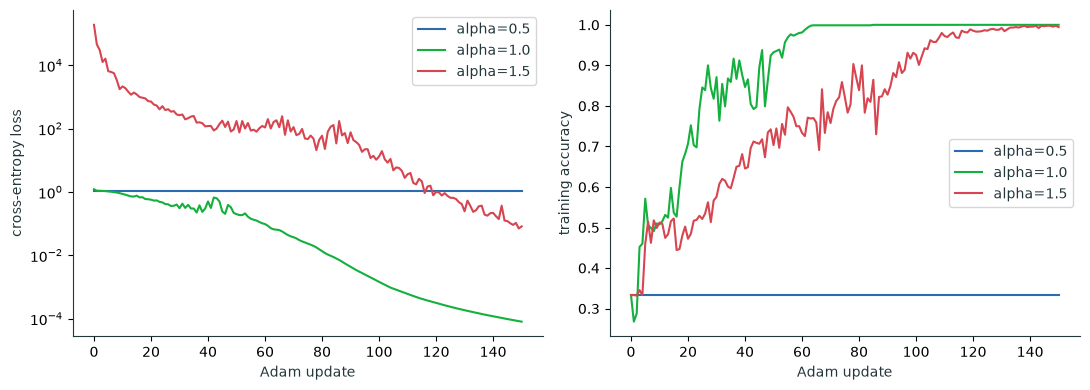

alpha=0.5: loss 1.0986 -> 1.0986; accuracy 0.333 -> 0.333; first non-finite=None
alpha=1.0: loss 1.2242 -> 8.0662e-05; accuracy 0.333 -> 1.000; first non-finite=None
alpha=1.5: loss 1.8936e+05 -> 0.081935; accuracy 0.333 -> 0.994; first non-finite=None


In [8]:
@dataclass
class Run:
    steps: list
    loss: list
    accuracy: list
    first_nonfinite: int | None


def train(alpha, route="plain", steps=150, learning_rate=3e-4):
    model = DeepSpiralMLP(alpha, route=route)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    record = Run([], [], [], None)
    for step in range(steps + 1):
        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(X)
        loss = F.cross_entropy(logits, y)
        if not torch.isfinite(loss):
            record.first_nonfinite = step
            break
        record.steps.append(step)
        record.loss.append(loss.item())
        record.accuracy.append((logits.argmax(dim=1) == y).float().mean().item())
        if step < steps:
            loss.backward()
            optimizer.step()
    return model, record


fate_runs = {alpha: train(alpha)[1] for alpha in (0.5, 1.0, 1.5)}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for alpha, run in fate_runs.items():
    axes[0].plot(run.steps, np.maximum(run.loss, 1e-7), color=colors[alpha], label=f"alpha={alpha}")
    axes[1].plot(run.steps, run.accuracy, color=colors[alpha], label=f"alpha={alpha}")
axes[0].set_yscale("log")
axes[0].set_ylabel("cross-entropy loss")
axes[1].set_ylabel("training accuracy")
for ax in axes:
    ax.set_xlabel("Adam update")
    ax.legend()
plt.tight_layout(); plt.show()

for alpha, run in fate_runs.items():
    print(
        f"alpha={alpha}: loss {run.loss[0]:.5g} -> {run.loss[-1]:.5g}; "
        f"accuracy {run.accuracy[0]:.3f} -> {run.accuracy[-1]:.3f}; "
        f"first non-finite={run.first_nonfinite}"
    )

The $α=1.5$ initialization is **numerically absurd, but not divergent in
this run**. Its layer-30 activation RMS is about $2.1\times10^5$, its initial
loss is about $1.9\times10^5$, and yet Adam rescues it to high accuracy. A
divergence diagnosis would require growing/unbounded or non-finite values; here
`first_nonfinite=None`. Rescue is evidence of Adam's robustness, not evidence
that this was a sensible initialization.

The output geometry makes the three fates easier to see. Retrain each model for
exactly 50 updates, then inspect what decision regions it has built.

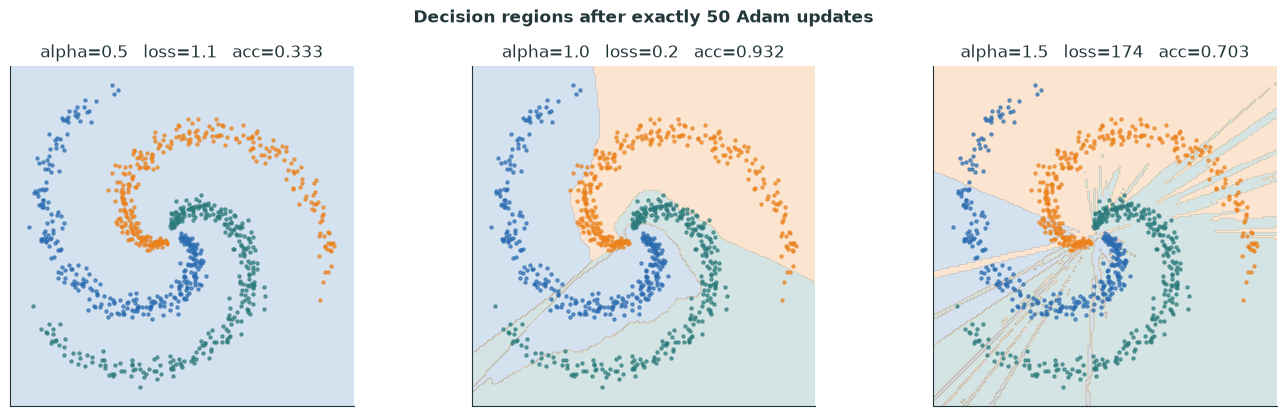

In [9]:
boundary_results = {alpha: train(alpha, steps=50) for alpha in (0.5, 1.0, 1.5)}

x_min, x_max = X[:, 0].min().item() - 0.12, X[:, 0].max().item() + 0.12
y_min, y_max = X[:, 1].min().item() - 0.12, X[:, 1].max().item() + 0.12
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 180),
    np.linspace(y_min, y_max, 180),
)
grid = torch.tensor(np.c_[grid_x.ravel(), grid_y.ravel()], dtype=X.dtype)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True, sharey=True)
class_colors = (TEAL, ACC, BLUE)
for ax, alpha in zip(axes, (0.5, 1.0, 1.5)):
    model, run = boundary_results[alpha]
    model.eval()
    with torch.no_grad():
        prediction = model(grid)[0].argmax(dim=1).reshape(grid_x.shape).numpy()
    ax.contourf(
        grid_x,
        grid_y,
        prediction,
        levels=(-0.5, 0.5, 1.5, 2.5),
        colors=class_colors,
        alpha=0.20,
    )
    for class_id, color in enumerate(class_colors):
        mask = y == class_id
        ax.scatter(X[mask, 0], X[mask, 1], s=5, color=color, alpha=0.65)
    ax.set_title(
        f"alpha={alpha}   loss={run.loss[-1]:.3g}   acc={run.accuracy[-1]:.3f}"
    )
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Decision regions after exactly 50 Adam updates", fontweight="bold")
plt.tight_layout(); plt.show()

## 7 · A healthy start can drift

Initialization establishes a sensible scale once. Train the $\alpha=1$ model
for 20 updates and compare its activation RMS with the initialization trace.

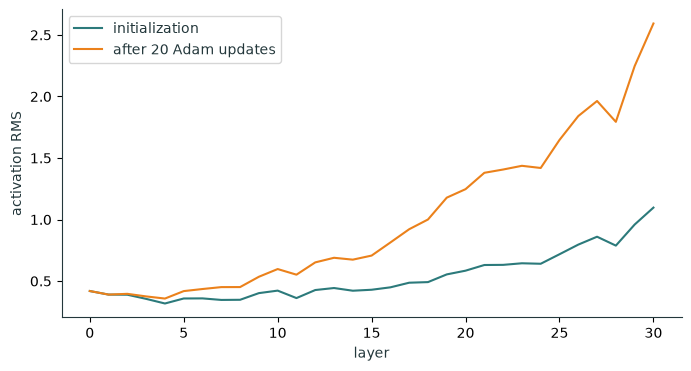

last-layer RMS: 1.097 -> 2.593


In [10]:
def activation_rms(model):
    model.eval()
    with torch.no_grad():
        _, activations = model(X)
    model.train()
    return [rms(X), *[rms(h) for h in activations]]


drift_model = DeepSpiralMLP(1.0)
before = activation_rms(drift_model)
optimizer = torch.optim.Adam(drift_model.parameters(), lr=3e-4)
for _ in range(20):
    optimizer.zero_grad(set_to_none=True)
    logits, _ = drift_model(X)
    F.cross_entropy(logits, y).backward()
    optimizer.step()
after = activation_rms(drift_model)

plt.plot(before, color=TEAL, label="initialization")
plt.plot(after, color=ACC, label="after 20 Adam updates")
plt.xlabel("layer"); plt.ylabel("activation RMS"); plt.legend(); plt.show()
print("last-layer RMS:", round(before[-1], 3), "->", round(after[-1], 3))

## 8 · Repair the collapsing route

Return to $\alpha=0.5$. Keep the same data, depth, width, loss, optimizer, and
learning rate. Compare:

1. plain `Linear → ReLU`;
2. `Linear → BatchNorm → ReLU`;
3. an exact identity skip `x + ReLU(Linear(x))` after the input stem.

For a residual block $h_{\ell+1}=h_\ell+F_\ell(h_\ell)$, the local Jacobian is

$$
\frac{\partial h_{\ell+1}}{\partial h_\ell}=I+J_{F_\ell}.
$$

The $I$ is a direct route for the backward signal. In the code above,
$F_\ell(h)=\operatorname{ReLU}(W_\ell h)$; there is no outer ReLU after the
addition. The stem first maps 2 coordinates to width 128 so every identity skip
has matching shape.

This is a mechanism comparison, not a universal ranking of architectures.

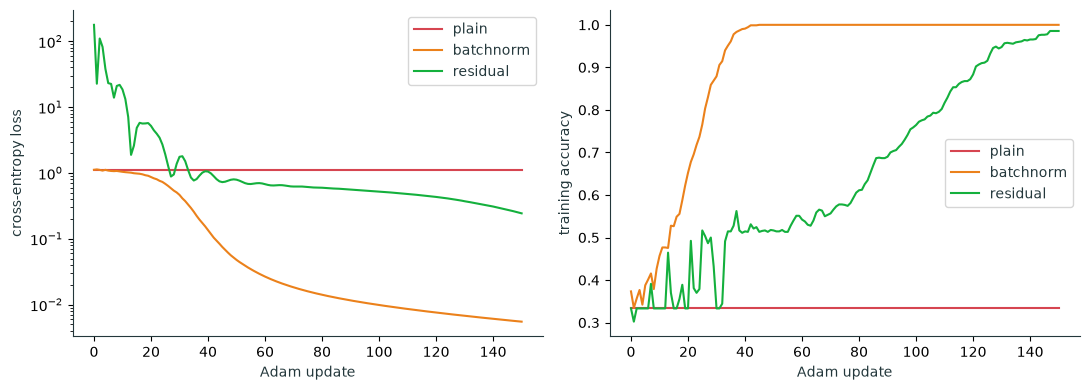

plain     : loss 1.0986 -> 1.0986; accuracy 0.333 -> 0.333
batchnorm : loss 1.1167 -> 0.0055048; accuracy 0.373 -> 1.000
residual  : loss 177.84 -> 0.24339; accuracy 0.333 -> 0.986


In [11]:
routes = ("plain", "batchnorm", "residual")
route_colors = {"plain": RED, "batchnorm": ACC, "residual": GREEN}
repair_runs = {route: train(0.5, route=route)[1] for route in routes}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for route, run in repair_runs.items():
    axes[0].plot(run.steps, np.maximum(run.loss, 1e-7), color=route_colors[route], label=route)
    axes[1].plot(run.steps, run.accuracy, color=route_colors[route], label=route)
axes[0].set_yscale("log")
axes[0].set_ylabel("cross-entropy loss")
axes[1].set_ylabel("training accuracy")
for ax in axes:
    ax.set_xlabel("Adam update")
    ax.legend()
plt.tight_layout(); plt.show()

for route, run in repair_runs.items():
    print(
        f"{route:10s}: loss {run.loss[0]:.5g} -> {run.loss[-1]:.5g}; "
        f"accuracy {run.accuracy[0]:.3f} -> {run.accuracy[-1]:.3f}"
    )

## 9 · Diagnose before prescribing

For each new failure, write three lines before changing code:

- **symptom** — what the loss or accuracy did;
- **measurement** — activation RMS, activation-gradient RMS, active fraction,
  or the first non-finite layer/update;
- **smallest controlled test** — one change that distinguishes the leading
  suspect from its alternatives.

The lecture's final claim is deliberately conditional:

> Mechanisms guide us; layerwise measurements decide what the network needs.